## Stack Overflow Developer Survey 2024, EDA Notebook

This notebook walks through the full exploratory data analysis pipeline:
1. Load & inspect the raw dataset
2. Data cleaning
3. Univariate analysis
4. Bivariate analysis
5. Key findings

**Dataset source:** https://survey.stackoverflow.co/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 5)

### 1. Load the dataset

In [2]:
# Place results.csv one level up (next to app.py)
df = pd.read_csv('../results.csv', low_memory=False)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (65437, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN


In [3]:
# Column overview
df.dtypes.to_frame('dtype').join(df.isnull().sum().to_frame('nulls'))

,dtype,nulls
ResponseId,int64,0
MainBranch,str,0
Age,str,0
Employment,str,0
RemoteWork,str,10631
...,...,...
JobSatPoints_11,float64,35992
SurveyLength,str,9255
SurveyEase,str,9199
ConvertedCompYearly,float64,42002


### 2. Data cleaning

In [4]:
# Keep columns we'll actually use
COLS = [
    'Age', 'EdLevel', 'Employment', 'RemoteWork',
    'YearsCodePro', 'DevType', 'LanguageHaveWorkedWith',
    'ConvertedCompYearly', 'Country', 'AISelect', 'AISent', 'JobSat'
]
df = df[[c for c in COLS if c in df.columns]].copy()

# Fix YearsCodePro text values
df['YearsCodePro'] = df['YearsCodePro'].replace(
    {'Less than 1 year': 0, 'More than 50 years': 51}
)
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Remove salary outliers
df = df[
    df['ConvertedCompYearly'].isna() |
    ((df['ConvertedCompYearly'] >= 1000) & (df['ConvertedCompYearly'] <= 1_000_000))
]

# Employment: take first value from multi-select
df['Employment'] = df['Employment'].str.split(';').str[0].str.strip()

# Experience bands
df['ExperienceBand'] = pd.cut(
    df['YearsCodePro'],
    bins=[-1, 0, 2, 5, 10, 20, 100],
    labels=['<1 yr', '1-2 yrs', '3-5 yrs', '6-10 yrs', '11-20 yrs', '20+ yrs']
)

df.reset_index(drop=True, inplace=True)
print(f'Clean shape: {df.shape}')
df.head(3)

Clean shape: (64851, 13)


,Age,EdLevel,Employment,RemoteWork,YearsCodePro,DevType,LanguageHaveWorkedWith,ConvertedCompYearly,Country,AISelect,AISent,JobSat,ExperienceBand
0,Under 18 years old,Primary/elementary school,"Employed, full-time",Remote,NaN,NaN,NaN,NaN,United States of America,Yes,Very favorable,NaN,NaN
1,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Employed, full-time",Remote,17.0,"Developer, full-stack",Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,NaN,United Kingdom of Great Britain and Northern I...,"No, and I don't plan to",NaN,NaN,11-20 yrs
2,45-54 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Employed, full-time",Remote,27.0,Developer Experience,C#,NaN,United Kingdom of Great Britain and Northern I...,"No, and I don't plan to",NaN,NaN,20+ yrs


### 3. Univariate analysis

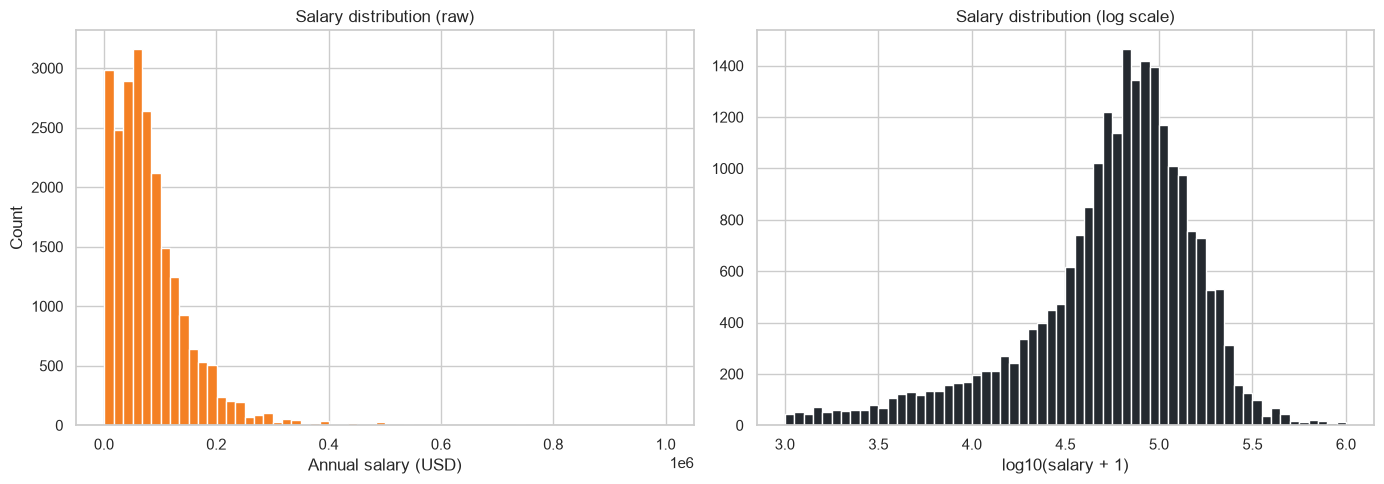

In [5]:
# Salary distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sal = df['ConvertedCompYearly'].dropna()
axes[0].hist(sal, bins=60, color='#F48024', edgecolor='white')
axes[0].set_title('Salary distribution (raw)')
axes[0].set_xlabel('Annual salary (USD)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log10(sal + 1), bins=60, color='#24292F', edgecolor='white')
axes[1].set_title('Salary distribution (log scale)')
axes[1].set_xlabel('log10(salary + 1)')

plt.tight_layout()
plt.show()

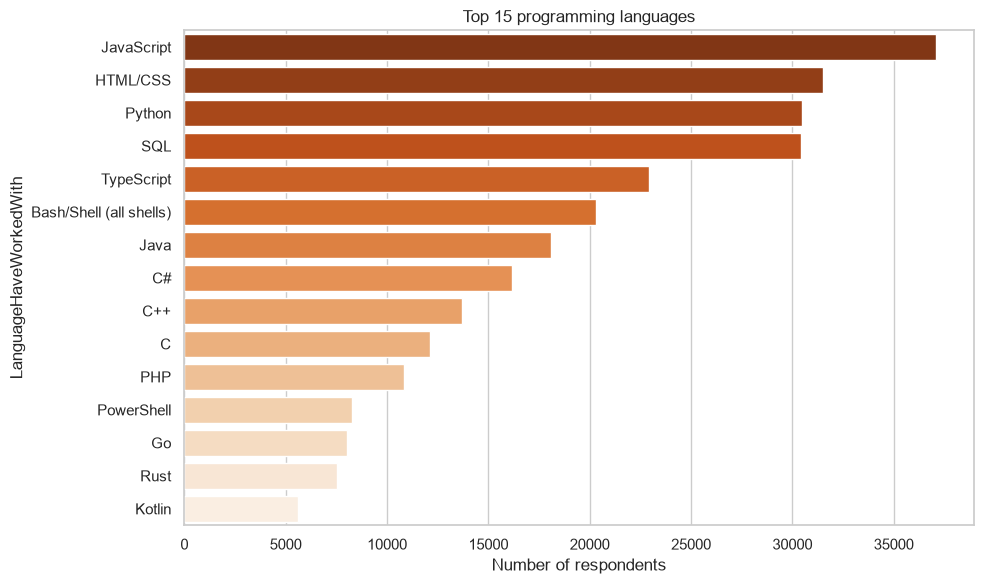

In [6]:
# Top 15 programming languages
lang_counts = (
    df['LanguageHaveWorkedWith']
    .dropna()
    .str.split(';')
    .explode()
    .str.strip()
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=lang_counts.values, y=lang_counts.index, palette='Oranges_r')
plt.title('Top 15 programming languages')
plt.xlabel('Number of respondents')
plt.tight_layout()
plt.show()

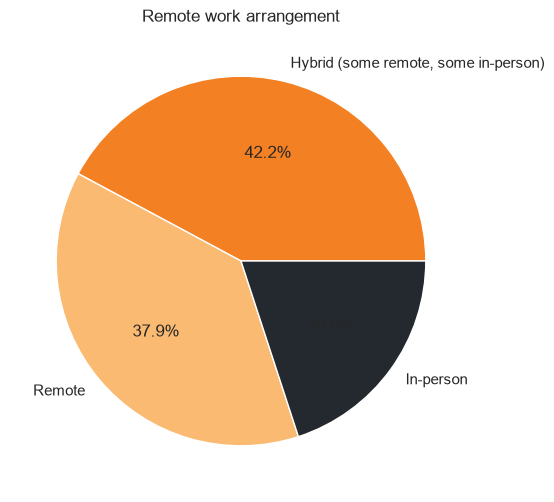

In [7]:
# Remote work distribution
remote = df['RemoteWork'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(remote.values, labels=remote.index, autopct='%1.1f%%',
        colors=['#F48024', '#FBBA72', '#24292F'])
plt.title('Remote work arrangement')
plt.show()

### 4. Bivariate analysis

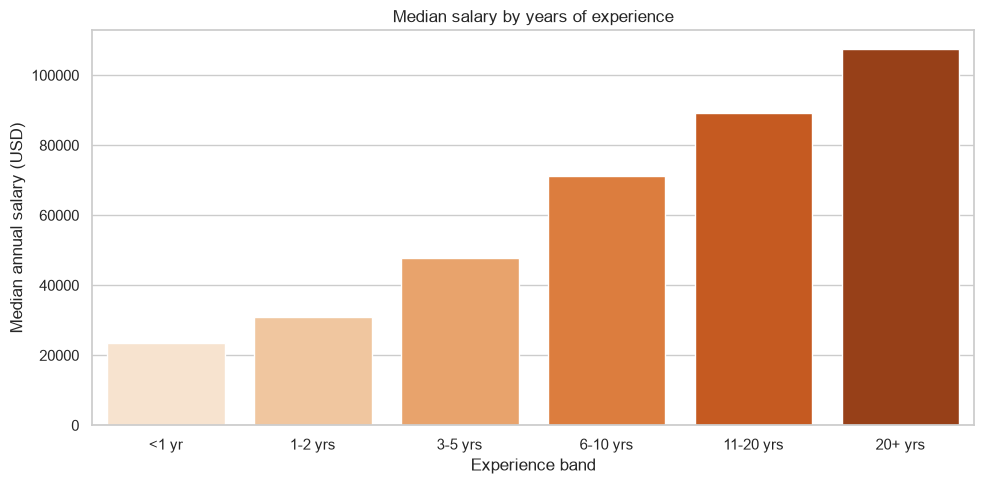

In [8]:
# Median salary by experience band
sal_exp = df.groupby('ExperienceBand', observed=True)['ConvertedCompYearly'].median().dropna()

plt.figure(figsize=(10, 5))
sns.barplot(x=sal_exp.index, y=sal_exp.values, palette='Oranges')
plt.title('Median salary by years of experience')
plt.xlabel('Experience band')
plt.ylabel('Median annual salary (USD)')
plt.tight_layout()
plt.show()

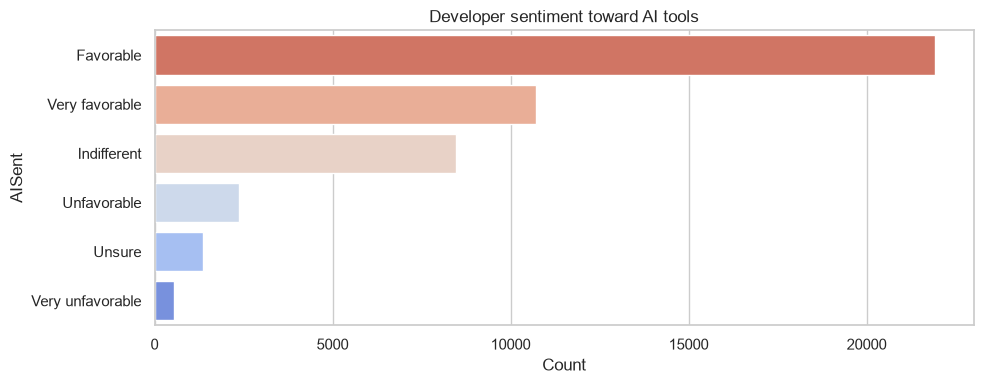

In [9]:
# AI sentiment breakdown
ai = df['AISent'].value_counts()
plt.figure(figsize=(10, 4))
sns.barplot(x=ai.values, y=ai.index, palette='coolwarm_r')
plt.title('Developer sentiment toward AI tools')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

### 5. Key Findings

**Most popular language**
JavaScript leads with **37,103 respondents** (~57% of those who answered), followed by HTML/CSS (31,525), Python (30,489), and SQL (30,409). TypeScript rounds out the top 5 at 22,919.

**Median salary — global vs top 3 countries**
| Scope | Median Annual Salary (USD) |
|---|---|
| Global | $66,769 |
| United States | $144,000 |
| United Kingdom | $84,267 |
| Germany | $73,036 |

US salaries are more than **2× the global median**, while UK and Germany sit 25–27% above it.

**AI tool adoption**
**61.7%** of respondents (37,231 out of 60,321) are currently using AI tools in their workflow. An additional 13.8% plan to start soon, meaning fewer than 25% have no plans to adopt AI tools.

**Remote work and pay**
Remote workers earn noticeably more:
| Work arrangement | Median Salary (USD) |
|---|---|
| Remote | $76,373 |
| Hybrid | $67,279 |
| In-person | $46,185 |

Fully remote developers earn **65% more** than in-person developers at the median, and ~14% more than hybrid workers. This likely reflects a combination of geographic selection (remote roles attract higher-paying markets) and the types of roles that offer full remote flexibility.